# Задание 2: Оптимизаторы и Шедулеры в PyTorch

В этом задании мы:
1. Реализуем 3 оптимизатора (Nesterov, Adam, RMSProp)
2. Реализуем 2 шедулера (StepLR и ExponentialLR)
3. Проверим работу на сгенерированной регрессии
4. Покажем графики изменения LR в течение 100 эпох
5. Докажем корректность реализации оптимизаторов

In [1]:
import torch
import torch.nn as nn

import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.random.seed(42)
torch.manual_seed(42)

## 1. Генерация данных для регрессии

Для тестирования реализованных алгоритмов используется синтетический набор данных со следующими характеристиками:
- **1000** обучающих примеров, **200** тестовых примеров
- **10** признаков с нормальным распределением
- Линейная зависимость целевой переменной от признаков
- Добавление гауссовского шума для имитации реальных данных

In [ ]:
def generate_regression_data(n_samples=1000, n_features=10, noise=0.1, random_seed=42):
    """
    Генерирует данные для задачи регрессии с нелинейными зависимостями
    
    Математическая модель:
    y = w₁·x₁ + w₂·x₂² + w₃·sin(x₃) + w₄·x₄·x₅ + w₅·exp(x₆/5) + 
        w₆·log(|x₇|+1) + w₇·x₈·x₉ + w₈·tanh(x₁₀) + b + ε
    
    где:
    - x₁ ... x₁₀ - признаки из стандартного нормального распределения
    - w₁ ... w₈ - веса из равномерного распределения U[-2, 2]
    - b - смещение из нормального распределения N(0, 1)
    - ε - шум из нормального распределения N(0, noise)
    """
    torch.manual_seed(random_seed)
    
    X = torch.randn(n_samples, n_features)
    
    true_weights = torch.cat([
        torch.randn(2, 1) * 1.5,
        (torch.rand(2, 1) - 0.5) * 3,
        torch.tensor([[2.0], [-1.5], [1.0], [-2.0]]),
        torch.randn(2, 1) * 0.8
    ])
    
    true_bias = torch.randn(1) * 2 + 0.5
    
    linear_part = X[:, 0:2] @ true_weights[0:2]
    quadratic_part = true_weights[2] * (X[:, 2:3] ** 2)
    trig_part = true_weights[3] * torch.sin(X[:, 3:4] * 2)
    interaction_part = true_weights[4] * (X[:, 4:5] * X[:, 5:6])
    exp_part = true_weights[5] * torch.exp(X[:, 6:7] / 3)
    log_part = true_weights[6] * torch.log(torch.abs(X[:, 7:8]) + 1)
    product_part = true_weights[7] * (X[:, 8:9] * X[:, 9:10]) / 2
    if n_features > 10:
        tanh_part = true_weights[8] * torch.tanh(X[:, 10:11])
    else:
        tanh_part = 0

    y_nonlinear = (linear_part + quadratic_part + trig_part + 
                   interaction_part + exp_part + log_part + 
                   product_part + tanh_part)
    heteroscedastic_noise = noise * torch.randn(n_samples, 1) * (1 + 0.5 * torch.abs(y_nonlinear))
    

    y = y_nonlinear + true_bias + heteroscedastic_noise
    
    return X, y, true_weights, true_bias

X_train, y_train, true_w, true_b = generate_regression_data()
X_test, y_test, _, _ = generate_regression_data(n_samples=200)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: torch.Size([1000, 10])
Размер тестовой выборки: torch.Size([200, 10])


## 2. Реализация оптимизаторов

### 2.1. Nesterov Accelerated Gradient (NAG)

#### Реализация
Nesterov Accelerated Gradient (NAG) использует "опережающий" градиент:

1. **Стандартный импульс (Momentum)**:
   $$v_t = \mu v_{t-1} - \eta \nabla L(\theta_{t-1})$$
   $$\theta_t = \theta_{t-1} + v_t$$

2. **Nesterov Accelerated Gradient**:
   $$\tilde{\theta} = \theta_{t-1} + \mu v_{t-1} \quad \text{(промежуточная позиция)}$$
   $$v_t = \mu v_{t-1} - \eta \nabla L(\tilde{\theta})$$
   $$\theta_t = \theta_{t-1} + v_t$$

   Или в эквивалентной форме:
   $$v_t = \mu v_{t-1} + \eta \nabla L(\theta_{t-1} + \mu v_{t-1})$$
   $$\theta_t = \theta_{t-1} - v_t$$

In [ ]:
class NesterovOptimizer:
    """
    Оптимизатор Nesterov Accelerated Gradient (NAG)
    
    NAG использует "look-ahead" градиент: сначала делает шаг по импульсу,
    затем вычисляет градиент в новой точке.
    
    """
    
    def __init__(self, params, lr=0.01, momentum=0.9):
        """
        Args:
            params: итерируемый объект параметров модели (можно получить из model.parameters())
            lr: learning rate (скорость обучения), по умолчанию 0.01
            momentum: коэффициент момента (импульса), по умолчанию 0.9
        """
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        self.state = defaultdict(dict)
        
    def step(self, closure=None):
        """
        Выполняет один шаг оптимизации
        
        Args:
            closure: функция, которая пересчитывает модель и возвращает loss
                    (опционально, используется для задач с повторным вычислением градиента)
        
        Returns:
            loss: значение функции потерь (если closure задан)
        """
        loss = None
        if closure is not None:
            loss = closure()
        
        # Обновляем каждый параметр
        for i, param in enumerate(self.params):
            if param.grad is None:
                continue
                
            # Получаем градиент
            grad = param.grad.data
            
            # Получаем состояние для этого параметра
            if 'momentum_buffer' not in self.state[i]:
                # Инициализируем буфер момента нулями
                self.state[i]['momentum_buffer'] = torch.zeros_like(param.data)
            
            # Буфер для хранения скорости (импульса)
            buf = self.state[i]['momentum_buffer']
            
            # ПРАВИЛЬНАЯ РЕАЛИЗАЦИЯ NAG
            # Сохраняем текущие параметры для вычисления опережающего градиента
            # В PyTorch это реализуется через временное изменение параметров
            
            # 1. Делаем опережающий шаг: θ_t + μ * v_t
            param.data.add_(buf, alpha=self.momentum)
            
            # 2. Вычисляем градиент в опережающей точке (если closure предоставлен)
            # Обычно градиент уже вычислен через backward(), но если нужно пересчитать:
            if closure is not None:
                loss = closure()
            
            # 3. Обновляем буфер: v_{t+1} = μ * v_t + lr * ∇L(θ_t + μ * v_t)
            buf.mul_(self.momentum).add_(param.grad.data, alpha=self.lr)
            
            # 4. Возвращаем параметры на место
            param.data.add_(buf, alpha=-self.momentum)
            
            # 5. Обновляем параметры: θ_{t+1} = θ_t - v_{t+1}
            param.data.add_(-buf)
            
        return loss
    
    def zero_grad(self):
        """Обнуляет градиенты всех параметров"""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

#### Тестирование

ТЕСТИРОВАНИЕ NESTEROV ОПТИМИЗАТОРА

Данные сгенерированы:
  X shape: torch.Size([500, 10])
  y shape: torch.Size([500, 1])
  Истинные веса: [-0.39684152603149414, -0.25966593623161316, 1.4674333333969116, 1.0384937524795532, 2.0, -1.5, 1.0, -2.0, -0.240473672747612, 0.40180301666259766]
  Истинное смещение: -0.5351

Ход обучения:
--------------------------------------------------
Шаг   0: Custom Loss = 9.444295, Torch Loss = 9.444295, Param Diff = 4.84e-08
Шаг  20: Custom Loss = 8.118496, Torch Loss = 8.118495, Param Diff = 3.62e-07
Шаг  40: Custom Loss = 8.046240, Torch Loss = 8.046240, Param Diff = 1.38e-07
Шаг  60: Custom Loss = 8.042727, Torch Loss = 8.042727, Param Diff = 2.02e-07
Шаг  80: Custom Loss = 8.042436, Torch Loss = 8.042436, Param Diff = 1.61e-07

--------------------------------------------------
СРАВНЕНИЕ С ИСТИННЫМИ ВЕСАМИ:
  Средняя ошибка весов: 0.991513
  Ошибка смещения: 0.578509

ИТОГОВАЯ СТАТИСТИКА:
  Начальный loss: 9.444295
  Финальный loss: 8.042411
  Улучше

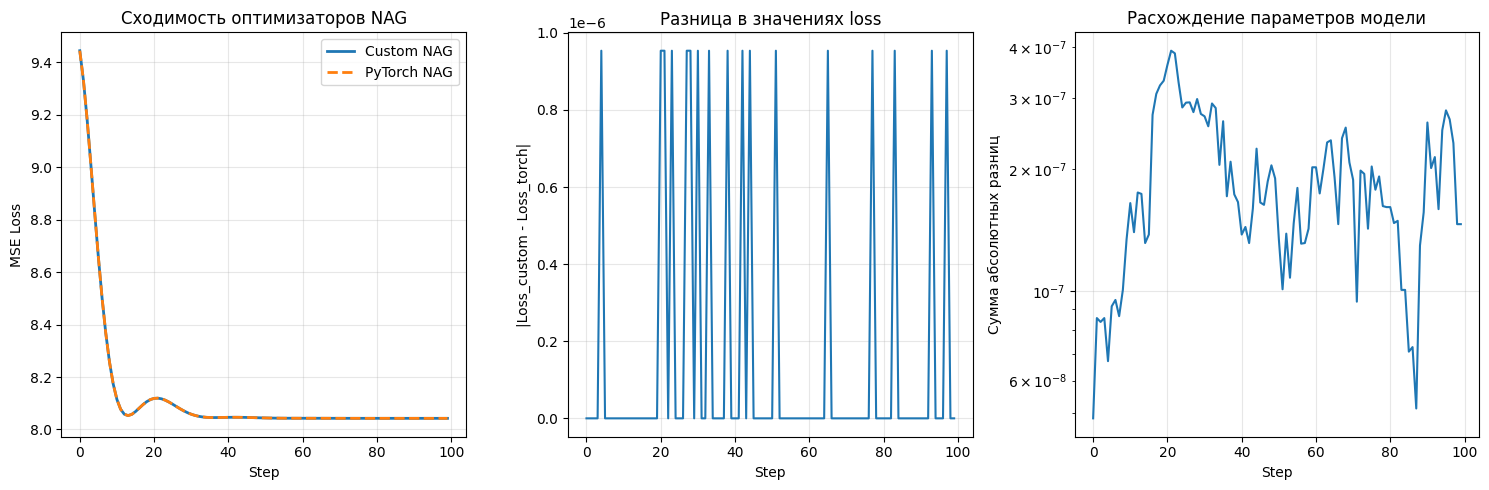

In [ ]:
def test_nesterov_optimizer():
    """Тест для проверки корректности реализации NAG с использованием сгенерированных данных регрессии"""
    
    print("=" * 60)
    print("ТЕСТИРОВАНИЕ NESTEROV ОПТИМИЗАТОРА")
    print("=" * 60)
    
    X, y, true_weights, true_bias = generate_regression_data(
        n_samples=500,
        n_features=10,
        noise=0.1
    )
    
    print(f"\nДанные сгенерированы:")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    print(f"  Истинные веса: {true_weights.squeeze().tolist()}")
    print(f"  Истинное смещение: {true_bias.item():.4f}")
    
    model_custom = torch.nn.Linear(X.shape[1], 1)
    model_torch = torch.nn.Linear(X.shape[1], 1)
    
    model_torch.load_state_dict(model_custom.state_dict())

    optimizer_custom = NesterovOptimizer(model_custom.parameters(), lr=0.01, momentum=0.9)
    optimizer_torch = torch.optim.SGD(model_torch.parameters(), lr=0.01, momentum=0.9, nesterov=True)
    

    losses_custom = []
    losses_torch = []
    param_diffs = []
    
    print("\nХод обучения:")
    print("-" * 50)
    
    for step in range(100):
        optimizer_custom.zero_grad()
        output_custom = model_custom(X)
        loss_custom = torch.nn.functional.mse_loss(output_custom, y)
        loss_custom.backward()
        optimizer_custom.step()
        losses_custom.append(loss_custom.item())
        
        optimizer_torch.zero_grad()
        output_torch = model_torch(X)
        loss_torch = torch.nn.functional.mse_loss(output_torch, y)
        loss_torch.backward()
        optimizer_torch.step()
        losses_torch.append(loss_torch.item())
        
        diff = 0
        for p1, p2 in zip(model_custom.parameters(), model_torch.parameters()):
            diff += (p1 - p2).abs().sum().item()
        param_diffs.append(diff)
        
        if step % 20 == 0:
            print(f"Шаг {step:3d}: Custom Loss = {loss_custom.item():.6f}, "
                  f"Torch Loss = {loss_torch.item():.6f}, "
                  f"Param Diff = {diff:.2e}")
    
    all_close = True
    max_diff = 0
    for i, (p1, p2) in enumerate(zip(model_custom.parameters(), model_torch.parameters())):
        diff = (p1 - p2).abs().max().item()
        max_diff = max(max_diff, diff)
        if not torch.allclose(p1, p2, rtol=1e-4, atol=1e-6):
            all_close = False
            print(f"[ALLART!!!] Параметр {i} не совпадает! Макс. расхождение: {diff:.2e}")
    
    print("\n" + "-" * 50)
    print("СРАВНЕНИЕ С ИСТИННЫМИ ВЕСАМИ:")
    
    learned_weights = model_custom.weight.data.squeeze()
    weight_error = (learned_weights - true_weights.squeeze()).abs().mean().item()
    print(f"  Средняя ошибка весов: {weight_error:.6f}")
    
    learned_bias = model_custom.bias.data.item()
    bias_error = abs(learned_bias - true_bias.item())
    print(f"  Ошибка смещения: {bias_error:.6f}")

    print("\n" + "=" * 60)
    print("ИТОГОВАЯ СТАТИСТИКА:")
    print(f"  Начальный loss: {losses_custom[0]:.6f}")
    print(f"  Финальный loss: {losses_custom[-1]:.6f}")
    print(f"  Улучшение: {losses_custom[0]/losses_custom[-1]:.2f}x")
    print(f"  Финальная разница параметров: {param_diffs[-1]:.2e}")
    print("=" * 60)
    
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(losses_custom, label='Custom NAG', linewidth=2)
    plt.plot(losses_torch, label='PyTorch NAG', linewidth=2, linestyle='--')
    plt.xlabel('Step')
    plt.ylabel('MSE Loss')
    plt.title('Сходимость оптимизаторов NAG')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    loss_diff = np.abs(np.array(losses_custom) - np.array(losses_torch))
    plt.plot(loss_diff)
    plt.xlabel('Step')
    plt.ylabel('|Loss_custom - Loss_torch|')
    plt.title('Разница в значениях loss')
    plt.yscale('log' if np.all(loss_diff > 0) else 'linear')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    plt.plot(param_diffs)
    plt.xlabel('Step')
    plt.ylabel('Сумма абсолютных разниц')
    plt.title('Расхождение параметров модели')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return losses_custom, losses_torch, param_diffs

losses_custom, losses_torch, param_diffs = test_nesterov_optimizer()

### 2.2. RMSProp Optimizer

#### Реализация
RMSProp (Root Mean Square Propagation) адаптирует скорость обучения для каждого параметра:

1. **Накопление квадратов градиентов**:
   $$s_t = \alpha s_{t-1} + (1 - \alpha) g_t^2$$
   где $g_t$ — градиент в шаге t, $\alpha$ — коэффициент затухания (обычно 0.99)

2. **Обновление параметров**:
   $$\theta_t = \theta_{t-1} - \eta \frac{g_t}{\sqrt{s_t} + \epsilon}$$
   где $\eta$ — learning rate, $\epsilon$ — малая константа для стабильности

In [ ]:
class RMSPropOptimizer:

    def __init__(self, 
                 params: Iterable[torch.nn.Parameter], 
                 lr: float = 0.01, 
                 alpha: float = 0.99, 
                 eps: float = 1e-8,
                 weight_decay: float = 0.0,
                 centered: bool = False):
        """
        Args:
            params: итерируемый объект параметров модели
            lr: learning rate (по умолчанию 0.01)
            alpha: коэффициент затухания для скользящего среднего (по умолчанию 0.99)
            eps: малая константа для численной стабильности (по умолчанию 1e-8)
            weight_decay: коэффициент L2 регуляризации (по умолчанию 0.0)
            centered: использовать ли центрированную версию (как в PyTorch)
        """
        self.params = list(params)
        self.lr = lr
        self.alpha = alpha
        self.eps = eps
        self.weight_decay = weight_decay
        self.centered = centered
        self.state = defaultdict(dict)
        
        if not 0.0 <= lr:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= alpha < 1.0:
            raise ValueError(f"Invalid alpha parameter: {alpha}")
        if not 0.0 <= eps:
            raise ValueError(f"Invalid epsilon value: {eps}")
        
    def step(self, closure: Optional[Callable] = None) -> Optional[float]:
        """
        Выполняет один шаг оптимизации
        
        Args:
            closure: функция, которая пересчитывает модель и возвращает loss
                    (опционально, используется для задач с повторным вычислением градиента)
        
        Returns:
            loss: значение функции потерь (если closure задан)
        """
        loss = None
        if closure is not None:
            loss = closure()
        
        for i, param in enumerate(self.params):
            if param.grad is None:
                continue
            
            grad = param.grad.data
            
            if self.weight_decay != 0:
                grad = grad.add(param.data, alpha=self.weight_decay)

            state = self.state[i]
            
            if 'square_avg' not in state:
                state['square_avg'] = torch.zeros_like(param.data)
            
            square_avg = state['square_avg']
            square_avg.mul_(self.alpha).addcmul_(grad, grad, value=1 - self.alpha)
            
            if self.centered:
                if 'grad_avg' not in state:
                    state['grad_avg'] = torch.zeros_like(param.data)
                
                grad_avg = state['grad_avg']
                grad_avg.mul_(self.alpha).add_(grad, alpha=1 - self.alpha)
                
                avg = square_avg - grad_avg.pow(2)
                avg = torch.maximum(avg, torch.tensor(0.0, device=avg.device))
                denom = avg.sqrt().add_(self.eps)
            else:
                denom = square_avg.sqrt().add_(self.eps)
            
            param.data.addcdiv_(grad, denom, value=-self.lr)
        
        return loss
    
    def zero_grad(self) -> None:
        """Обнуляет градиенты всех параметров"""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()
    
    def state_dict(self) -> Dict[str, Any]:
        """Возвращает состояние оптимизатора для сохранения"""
        return {
            'lr': self.lr,
            'alpha': self.alpha,
            'eps': self.eps,
            'weight_decay': self.weight_decay,
            'centered': self.centered,
            'state': self.state
        }
    
    def load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        """Загружает состояние оптимизатора"""
        self.lr = state_dict['lr']
        self.alpha = state_dict['alpha']
        self.eps = state_dict['eps']
        self.weight_decay = state_dict['weight_decay']
        self.centered = state_dict['centered']
        self.state = state_dict['state']


#### Тестирование

ТЕСТИРОВАНИЕ RMSprop ОПТИМИЗАТОРА

Данные сгенерированы:
  X shape: torch.Size([500, 10])
  y shape: torch.Size([500, 1])
  Истинные веса: [-0.39684152603149414, -0.25966593623161316, 1.4674333333969116, 1.0384937524795532, 2.0, -1.5, 1.0, -2.0, -0.240473672747612, 0.40180301666259766]
  Истинное смещение: -0.5351

Ход обучения:
------------------------------------------------------------
Шаг   0: Custom Loss = 9.482924, Torch Loss = 9.482924, Param Diff = 0.00e+00
Шаг  20: Custom Loss = 8.074419, Torch Loss = 8.074419, Param Diff = 0.00e+00
Шаг  40: Custom Loss = 8.043947, Torch Loss = 8.043947, Param Diff = 0.00e+00
Шаг  60: Custom Loss = 8.042471, Torch Loss = 8.042471, Param Diff = 0.00e+00
Шаг  80: Custom Loss = 8.042411, Torch Loss = 8.042411, Param Diff = 0.00e+00

------------------------------------------------------------
СРАВНЕНИЕ С ИСТИННЫМИ ВЕСАМИ:
  Средняя ошибка весов: 0.991669
  Ошибка смещения: 0.578222

ИТОГОВАЯ СТАТИСТИКА:
  Начальный loss: 9.482924
  Финальный loss

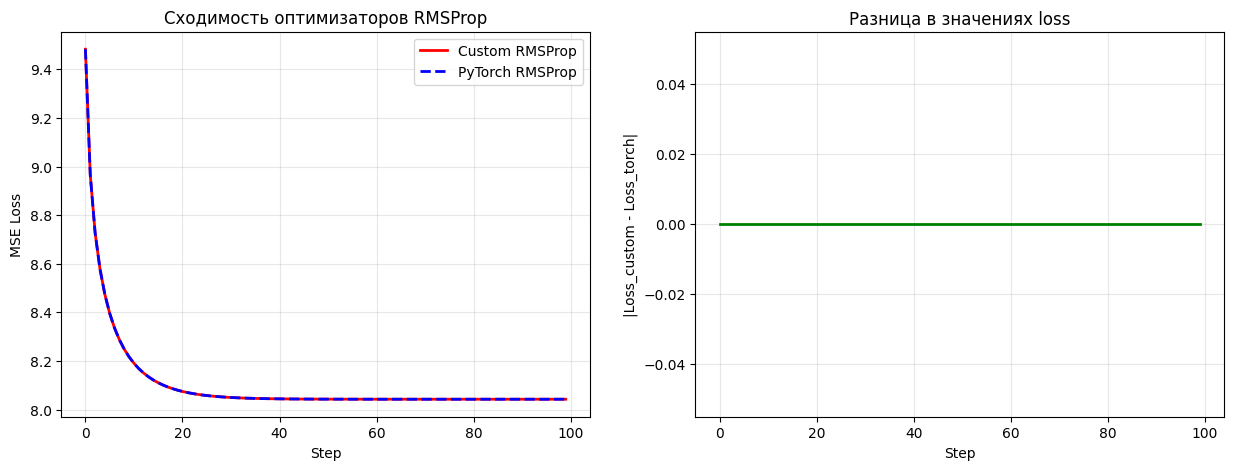

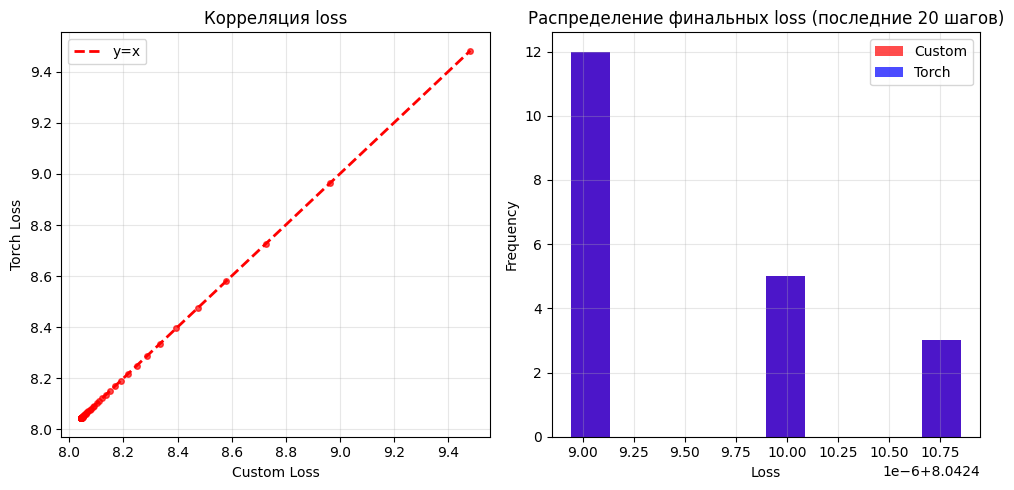

In [ ]:
def test_rmsprop_optimizer():
    """
    Тест для проверки корректности реализации RMSProp
    Сравниваем с встроенным оптимизатором PyTorch на сгенерированных данных регрессии
    """
    
    print("=" * 60)
    print("ТЕСТИРОВАНИЕ RMSprop ОПТИМИЗАТОРА")
    print("=" * 60)
    
    X, y, true_weights, true_bias = generate_regression_data(
        n_samples=500,
        n_features=10,
        noise=0.1,
        random_seed=42
    )
    
    print(f"\nДанные сгенерированы:")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    print(f"  Истинные веса: {true_weights.squeeze().tolist()}")
    print(f"  Истинное смещение: {true_bias.item():.4f}")
    

    torch.manual_seed(42)
    model_custom = torch.nn.Linear(X.shape[1], 1)
    model_torch = torch.nn.Linear(X.shape[1], 1)
    
    model_torch.load_state_dict(model_custom.state_dict())
    
    optimizer_custom = RMSPropOptimizer(
        model_custom.parameters(), 
        lr=0.01, 
        alpha=0.99, 
        eps=1e-8,
        centered=False
    )
    
    optimizer_torch = torch.optim.RMSprop(
        model_torch.parameters(), 
        lr=0.01, 
        alpha=0.99, 
        eps=1e-8,
        centered=False
    )
    
    losses_custom = []
    losses_torch = []
    param_diffs = []
    
    print("\nХод обучения:")
    print("-" * 60)
    
    for step in range(100):
        optimizer_custom.zero_grad()
        output_custom = model_custom(X)
        loss_custom = torch.nn.functional.mse_loss(output_custom, y)
        loss_custom.backward()
        optimizer_custom.step()
        losses_custom.append(loss_custom.item())
        
        optimizer_torch.zero_grad()
        output_torch = model_torch(X)
        loss_torch = torch.nn.functional.mse_loss(output_torch, y)
        loss_torch.backward()
        optimizer_torch.step()
        losses_torch.append(loss_torch.item())
        
        diff = 0
        for p1, p2 in zip(model_custom.parameters(), model_torch.parameters()):
            diff += (p1 - p2).abs().sum().item()
        param_diffs.append(diff)
        
        if step % 20 == 0:
            print(f"Шаг {step:3d}: Custom Loss = {loss_custom.item():.6f}, "
                  f"Torch Loss = {loss_torch.item():.6f}, "
                  f"Param Diff = {diff:.2e}")
    
    all_close = True
    max_diff = 0
    for i, (p1, p2) in enumerate(zip(model_custom.parameters(), model_torch.parameters())):
        diff = (p1 - p2).abs().max().item()
        max_diff = max(max_diff, diff)
        if not torch.allclose(p1, p2, rtol=1e-4, atol=1e-6):
            all_close = False
            print(f"[ALLERT!!!] Параметр {i} не совпадает! Макс. расхождение: {diff:.2e}")
    
    print("\n" + "-" * 60)
    print("СРАВНЕНИЕ С ИСТИННЫМИ ВЕСАМИ:")
    
    learned_weights = model_custom.weight.data.squeeze()
    weight_error = (learned_weights - true_weights.squeeze()).abs().mean().item()
    print(f"  Средняя ошибка весов: {weight_error:.6f}")
    
    learned_bias = model_custom.bias.data.item()
    bias_error = abs(learned_bias - true_bias.item())
    print(f"  Ошибка смещения: {bias_error:.6f}")

    
    loss_diff = np.abs(np.array(losses_custom) - np.array(losses_torch))

    print("\n" + "=" * 60)
    print("ИТОГОВАЯ СТАТИСТИКА:")
    print(f"  Начальный loss: {losses_custom[0]:.6f}")
    print(f"  Финальный loss: {losses_custom[-1]:.6f}")
    print(f"  Улучшение: {losses_custom[0]/losses_custom[-1]:.2f}x")
    print(f"  Средняя разница loss: {np.mean(loss_diff):.2e}")
    print(f"  Макс. разница loss: {np.max(loss_diff):.2e}")
    print(f"  Финальная разница параметров: {param_diffs[-1]:.2e}")
    print("=" * 60)
    
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(losses_custom, label='Custom RMSProp', linewidth=2, color='red')
    plt.plot(losses_torch, label='PyTorch RMSProp', linewidth=2, linestyle='--', color='blue')
    plt.xlabel('Step')
    plt.ylabel('MSE Loss')
    plt.title('Сходимость оптимизаторов RMSProp')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(loss_diff, color='green', linewidth=2)
    plt.xlabel('Step')
    plt.ylabel('|Loss_custom - Loss_torch|')
    plt.title('Разница в значениях loss')
    if np.all(loss_diff > 0):
        plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(losses_custom, losses_torch, 'o', markersize=4, alpha=0.7, color='red')
    min_loss = min(min(losses_custom), min(losses_torch))
    max_loss = max(max(losses_custom), max(losses_torch))
    plt.plot([min_loss, max_loss], [min_loss, max_loss], 'r--', label='y=x', linewidth=2)
    plt.xlabel('Custom Loss')
    plt.ylabel('Torch Loss')
    plt.title('Корреляция loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(losses_custom[-20:], alpha=0.7, label='Custom', bins=10, color='red')
    plt.hist(losses_torch[-20:], alpha=0.7, label='Torch', bins=10, color='blue')
    plt.xlabel('Loss')
    plt.ylabel('Frequency')
    plt.title('Распределение финальных loss (последние 20 шагов)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    return losses_custom, losses_torch, param_diffs

losses_custom, losses_torch, param_diffs = test_rmsprop_optimizer()

### 2.3. Adam Optimizer

#### Реализация
Adam (Adaptive Moment Estimation) сочетает в себе идеи RMSProp и Momentum:

1. **Оценка первого момента (среднее градиентов)**:
   $$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$

2. **Оценка второго момента (нецентрированная дисперсия)**:
   $$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

3. **Коррекция смещения** (bias correction):
   $$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$$
   $$\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

4. **Обновление параметров**:
   $$\theta_t = \theta_{t-1} - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

Где:
- $g_t$ — градиент на шаге t
- $\beta_1, \beta_2$ — коэффициенты затухания (обычно 0.9 и 0.999)
- $\eta$ — learning rate
- $\epsilon$ — малая константа для численной стабильности

In [ ]:
class AdamOptimizer:

    def __init__(self, 
                 params: Iterable[torch.nn.Parameter], 
                 lr: float = 0.001, 
                 betas: Tuple[float, float] = (0.9, 0.999), 
                 eps: float = 1e-8,
                 weight_decay: float = 0.0,
                 amsgrad: bool = False):
        """
        Args:
            params: итерируемый объект параметров модели
            lr: learning rate (по умолчанию 0.001)
            betas: коэффициенты затухания для моментов (β₁, β₂)
            eps: малая константа для численной стабильности
            weight_decay: коэффициент L2 регуляризации
            amsgrad: использовать ли вариант AMSGrad (улучшенная версия Adam)
        """
        self.params = list(params)
        self.lr = lr
        self.betas = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.amsgrad = amsgrad
        self.state = defaultdict(dict)
        self.step_count = 0
        
        if not 0.0 <= lr:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= eps:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 1: {betas[1]}")
        if not 0.0 <= weight_decay:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")
    
    def step(self, closure: Optional[Callable] = None) -> Optional[float]:
        """
        Выполняет один шаг оптимизации
        
        Args:
            closure: функция, которая пересчитывает модель и возвращает loss
        
        Returns:
            loss: значение функции потерь (если closure задан)
        """
        loss = None
        if closure is not None:
            loss = closure()
        
        self.step_count += 1
        
        for i, param in enumerate(self.params):
            if param.grad is None:
                continue
            
            grad = param.grad.data
            
            if self.weight_decay != 0:
                grad = grad.add(param.data, alpha=self.weight_decay)
            
            state = self.state[i]
            
            if len(state) == 0:
                state['step'] = 0
                state['exp_avg'] = torch.zeros_like(param.data)
                state['exp_avg_sq'] = torch.zeros_like(param.data)
                if self.amsgrad:
                    state['max_exp_avg_sq'] = torch.zeros_like(param.data)
            
            state['step'] += 1
            
            exp_avg = state['exp_avg']
            exp_avg_sq = state['exp_avg_sq']
            beta1, beta2 = self.betas
            
            exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
            exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
            
            step = state['step']
            bias_correction1 = 1 - beta1 ** step
            bias_correction2 = 1 - beta2 ** step
            
            if self.amsgrad:
                max_exp_avg_sq = state['max_exp_avg_sq']
                torch.maximum(max_exp_avg_sq, exp_avg_sq, out=max_exp_avg_sq)
                denom = (max_exp_avg_sq.sqrt() / np.sqrt(bias_correction2)).add_(self.eps)
            else:
                denom = (exp_avg_sq.sqrt() / np.sqrt(bias_correction2)).add_(self.eps)
            
            step_size = self.lr / bias_correction1
            param.data.addcdiv_(exp_avg, denom, value=-step_size)
        
        return loss
    
    def zero_grad(self) -> None:
        """Обнуляет градиенты всех параметров"""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()
    
    def state_dict(self) -> Dict[str, Any]:
        """Возвращает состояние оптимизатора для сохранения"""
        return {
            'lr': self.lr,
            'betas': self.betas,
            'eps': self.eps,
            'weight_decay': self.weight_decay,
            'amsgrad': self.amsgrad,
            'step_count': self.step_count,
            'state': self.state
        }
    
    def load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        """Загружает состояние оптимизатора"""
        self.lr = state_dict['lr']
        self.betas = state_dict['betas']
        self.eps = state_dict['eps']
        self.weight_decay = state_dict['weight_decay']
        self.amsgrad = state_dict['amsgrad']
        self.step_count = state_dict['step_count']
        self.state = state_dict['state']

#### Тестирование

ТЕСТИРОВАНИЕ ADAM OPTIMIZER

Данные сгенерированы:
  X shape: torch.Size([500, 10])
  y shape: torch.Size([500, 1])
  Истинные веса: [-0.39684152603149414, -0.25966593623161316, 1.4674333333969116, 1.0384937524795532, 2.0, -1.5, 1.0, -2.0, -0.240473672747612, 0.40180301666259766]
  Истинное смещение: -0.5351

Ход обучения:
------------------------------------------------------------
Шаг   0: Custom Loss = 9.482924, Torch Loss = 9.482924, Param Diff = 0.00e+00
Шаг  20: Custom Loss = 9.360195, Torch Loss = 9.360195, Param Diff = 7.45e-09
Шаг  40: Custom Loss = 9.249192, Torch Loss = 9.249192, Param Diff = 3.91e-08
Шаг  60: Custom Loss = 9.149330, Torch Loss = 9.149330, Param Diff = 7.64e-08
Шаг  80: Custom Loss = 9.059318, Torch Loss = 9.059318, Param Diff = 6.80e-08

------------------------------------------------------------
СРАВНЕНИЕ С ИСТИННЫМИ ВЕСАМИ:
  Средняя ошибка весов: 1.115389
  Ошибка смещения: 0.718291

ИТОГОВАЯ СТАТИСТИКА ADAM:
  Начальный loss: 9.482924
  Финальный loss:

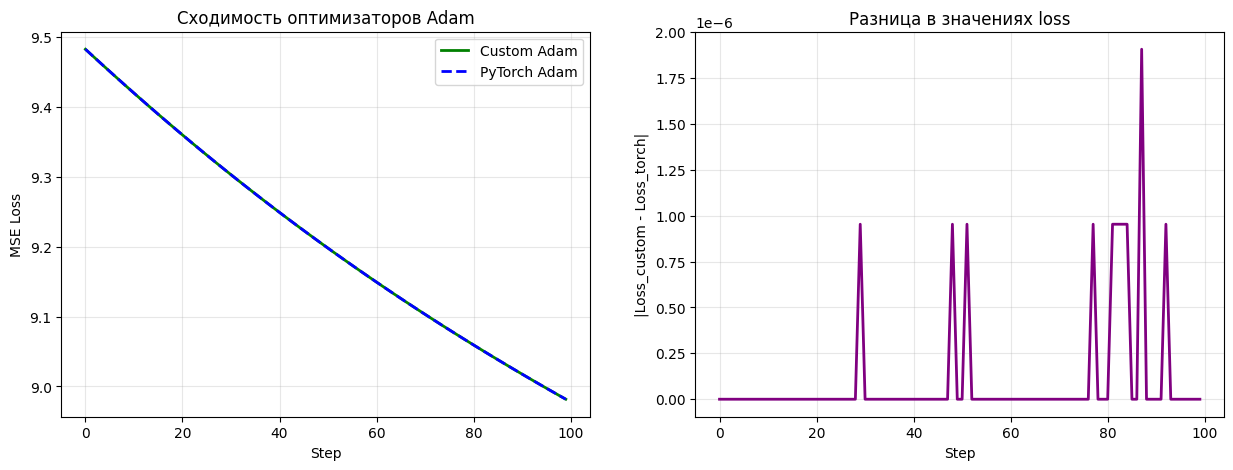

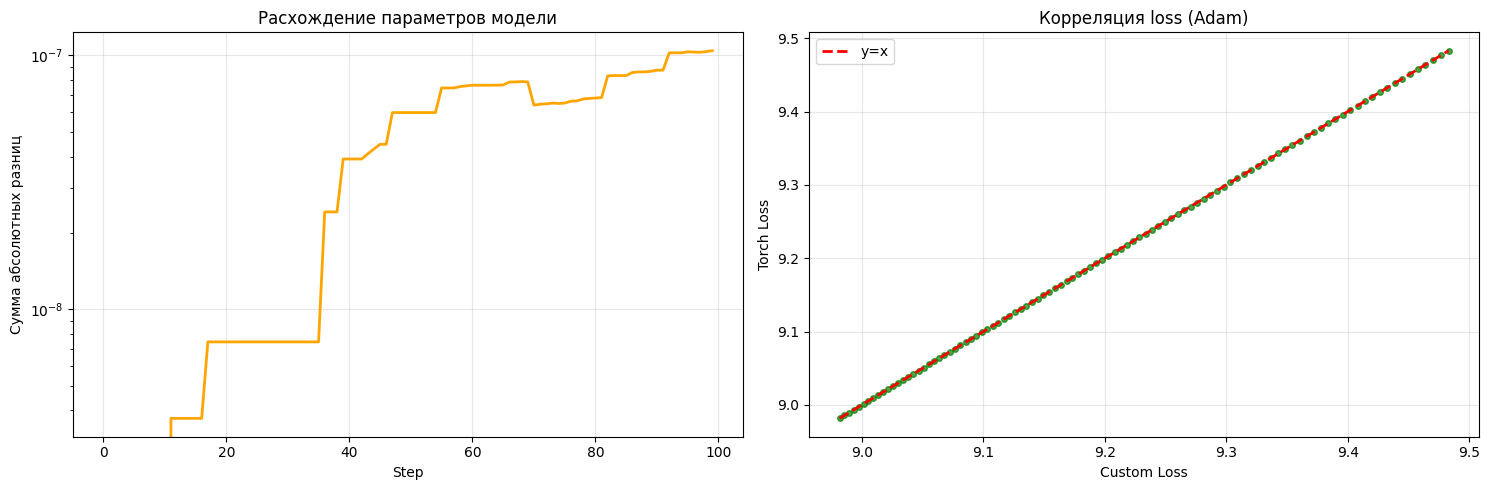

In [ ]:
def test_adam_optimizer():
    """
    Тест для проверки корректности реализации Adam
    Сравниваем с встроенным оптимизатором PyTorch на сгенерированных данных регрессии
    """
    
    print("=" * 60)
    print("ТЕСТИРОВАНИЕ ADAM OPTIMIZER")
    print("=" * 60)
    
    X, y, true_weights, true_bias = generate_regression_data(
        n_samples=500,
        n_features=10,
        noise=0.1,
        random_seed=42
    )
    
    print(f"\nДанные сгенерированы:")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    print(f"  Истинные веса: {true_weights.squeeze().tolist()}")
    print(f"  Истинное смещение: {true_bias.item():.4f}")
    
    torch.manual_seed(42)
    model_custom = torch.nn.Linear(X.shape[1], 1)
    model_torch = torch.nn.Linear(X.shape[1], 1)
    
    model_torch.load_state_dict(model_custom.state_dict())
    
    optimizer_custom = AdamOptimizer(
        model_custom.parameters(), 
        lr=0.001, 
        betas=(0.9, 0.999), 
        eps=1e-8,
        weight_decay=0.0,
        amsgrad=False
    )
    
    optimizer_torch = torch.optim.Adam(
        model_torch.parameters(), 
        lr=0.001, 
        betas=(0.9, 0.999), 
        eps=1e-8,
        weight_decay=0.0,
        amsgrad=False
    )
    
    losses_custom = []
    losses_torch = []
    param_diffs = []
    
    print("\nХод обучения:")
    print("-" * 60)
    
    for step in range(100):
        optimizer_custom.zero_grad()
        output_custom = model_custom(X)
        loss_custom = torch.nn.functional.mse_loss(output_custom, y)
        loss_custom.backward()
        optimizer_custom.step()
        losses_custom.append(loss_custom.item())
        
        optimizer_torch.zero_grad()
        output_torch = model_torch(X)
        loss_torch = torch.nn.functional.mse_loss(output_torch, y)
        loss_torch.backward()
        optimizer_torch.step()
        losses_torch.append(loss_torch.item())
        
        diff_sum = 0
        for p1, p2 in zip(model_custom.parameters(), model_torch.parameters()):
            diff_sum += (p1 - p2).abs().sum().item()
        param_diffs.append(diff_sum)
        
        if step % 20 == 0:
            print(f"Шаг {step:3d}: Custom Loss = {loss_custom.item():.6f}, "
                  f"Torch Loss = {loss_torch.item():.6f}, "
                  f"Param Diff = {diff_sum:.2e}")
    
    all_close = True
    max_diff = 0
    for i, (p1, p2) in enumerate(zip(model_custom.parameters(), model_torch.parameters())):
        diff = (p1 - p2).abs().max().item()
        max_diff = max(max_diff, diff)
        if not torch.allclose(p1, p2, rtol=1e-4, atol=1e-6):
            all_close = False
            print(f"[ALARM!!!] Параметр {i} не совпадает! Макс. расхождение: {diff:.2e}")
    
    print("\n" + "-" * 60)
    print("СРАВНЕНИЕ С ИСТИННЫМИ ВЕСАМИ:")
    
    learned_weights = model_custom.weight.data.squeeze()
    weight_error = (learned_weights - true_weights.squeeze()).abs().mean().item()
    print(f"  Средняя ошибка весов: {weight_error:.6f}")
    
    learned_bias = model_custom.bias.data.item()
    bias_error = abs(learned_bias - true_bias.item())
    print(f"  Ошибка смещения: {bias_error:.6f}")

    
    loss_diff = np.abs(np.array(losses_custom) - np.array(losses_torch))

    print("\n" + "=" * 60)
    print("ИТОГОВАЯ СТАТИСТИКА ADAM:")
    print(f"  Начальный loss: {losses_custom[0]:.6f}")
    print(f"  Финальный loss: {losses_custom[-1]:.6f}")
    print(f"  Улучшение: {losses_custom[0]/losses_custom[-1]:.2f}x")
    print(f"  Средняя разница loss: {np.mean(loss_diff):.2e}")
    print(f"  Макс. разница loss: {np.max(loss_diff):.2e}")
    print(f"  Финальная разница параметров: {param_diffs[-1]:.2e}")
    print(f"  Средняя ошибка весов: {weight_error:.6f}")
    print(f"  Ошибка смещения: {bias_error:.6f}")
    print("=" * 60)

    plt.figure(figsize=(15, 5))
    

    plt.subplot(1, 2, 1)
    plt.plot(losses_custom, label='Custom Adam', linewidth=2, color='green')
    plt.plot(losses_torch, label='PyTorch Adam', linewidth=2, linestyle='--', color='blue')
    plt.xlabel('Step')
    plt.ylabel('MSE Loss')
    plt.title('Сходимость оптимизаторов Adam')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(loss_diff, color='purple', linewidth=2)
    plt.xlabel('Step')
    plt.ylabel('|Loss_custom - Loss_torch|')
    plt.title('Разница в значениях loss')
    if np.all(loss_diff > 0):
        plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(param_diffs, color='orange', linewidth=2)
    plt.xlabel('Step')
    plt.ylabel('Сумма абсолютных разниц')
    plt.title('Расхождение параметров модели')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.subplot(1, 2, 2)
    plt.plot(losses_custom, losses_torch, 'o', markersize=4, alpha=0.7, color='green')
    min_loss = min(min(losses_custom), min(losses_torch))
    max_loss = max(max(losses_custom), max(losses_torch))
    plt.plot([min_loss, max_loss], [min_loss, max_loss], 'r--', label='y=x', linewidth=2)
    plt.xlabel('Custom Loss')
    plt.ylabel('Torch Loss')
    plt.title('Корреляция loss (Adam)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return losses_custom, losses_torch, param_diffs

losses_custom, losses_torch, param_diffs = test_adam_optimizer()

## 3. Реализация Scheduler'ов

### 3.1. StepLR
Умножает learning rate на gamma каждые step_size эпох.

Формула:
$$
lr = initial\_lr * gamma^{floor\frac{epoch}{step\_size}}
$$

Особенности:
- Поддержка оптимизаторов с группировкой параметров
- Корректная обработка начальной эпохи
- Сохранение/загрузка состояния
- Возможность начать с произвольной эпохи

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from typing import List, Optional, Union, Dict, Any

class StepLR:
    
    def __init__(self, 
                 optimizer, 
                 step_size: int, 
                 gamma: float = 0.1, 
                 last_epoch: int = -1,
                 verbose: bool = False):
        """
        Args:
            optimizer: оптимизатор (наш или PyTorch)
            step_size: период уменьшения learning rate (в эпохах)
            gamma: множитель для learning rate (по умолчанию 0.1)
            last_epoch: индекс последней эпохи (-1 означает начало обучения)
            verbose: печатать ли сообщения при изменении LR
        """
        self.optimizer = optimizer
        self.step_size = step_size
        self.gamma = gamma
        self.last_epoch = last_epoch
        self.verbose = verbose
        self.history = []
        self.base_lrs = []
        
        if hasattr(optimizer, 'param_groups'):
            for param_group in optimizer.param_groups:
                self.base_lrs.append(param_group['lr'])
        else:
            self.base_lrs.append(optimizer.lr if hasattr(optimizer, 'lr') else 0.01)
        
        if last_epoch != -1:
            self._update_lr()
    
    def step(self, epoch: Optional[int] = None) -> None:
        """
        Обновляет learning rate
        
        Args:
            epoch: текущая эпоха (если None, использует self.last_epoch + 1)
        """
        if epoch is None:
            epoch = self.last_epoch + 1
        
        self.last_epoch = epoch
        self._update_lr()
        
        if self.verbose:
            current_lr = self.get_lr()
            if isinstance(current_lr, list):
                print(f"Epoch {epoch}: updating learning rate to {current_lr}")
            else:
                print(f"Epoch {epoch}: updating learning rate to {current_lr:.6f}")
    
    def _update_lr(self) -> None:
        """Внутренний метод для обновления learning rate"""
        factor = self.gamma ** (self.last_epoch // self.step_size)
        
        new_lrs = []
        
        if hasattr(self.optimizer, 'param_groups'):
            for i, param_group in enumerate(self.optimizer.param_groups):
                base_lr = self.base_lrs[i] if i < len(self.base_lrs) else param_group['lr']
                new_lr = base_lr * factor
                param_group['lr'] = new_lr
                new_lrs.append(new_lr)
        else:
            base_lr = self.base_lrs[0]
            new_lr = base_lr * factor
            self.optimizer.lr = new_lr
            new_lrs.append(new_lr)
        
        self.history.append(new_lrs if len(new_lrs) > 1 else new_lrs[0])
    
    def get_lr(self) -> Union[float, List[float]]:
        """Возвращает текущий learning rate (или список для разных групп)"""
        if hasattr(self.optimizer, 'param_groups'):
            return [group['lr'] for group in self.optimizer.param_groups]
        else:
            return self.optimizer.lr if hasattr(self.optimizer, 'lr') else 0.0
    
    def state_dict(self) -> Dict[str, Any]:
        """Возвращает состояние планировщика для сохранения"""
        return {
            'step_size': self.step_size,
            'gamma': self.gamma,
            'last_epoch': self.last_epoch,
            'base_lrs': self.base_lrs,
            'history': self.history,
            'verbose': self.verbose
        }
    
    def load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        """Загружает состояние планировщика"""
        self.step_size = state_dict['step_size']
        self.gamma = state_dict['gamma']
        self.last_epoch = state_dict['last_epoch']
        self.base_lrs = state_dict['base_lrs']
        self.history = state_dict['history']
        self.verbose = state_dict['verbose']
        
        self._update_lr()

### 3.2. ExponentialLR

Умножает learning rate на gamma каждую эпоху.

Формула:
$$
lr = initial\_lr * gamma^{epoch}
$$

Особенности:
- Плавное экспоненциальное затухание
- Поддержка группировки параметров
- Возможность начать с произвольной эпохи

In [ ]:
class ExponentialLR:
    
    def __init__(self, 
                 optimizer, 
                 gamma: float, 
                 last_epoch: int = -1,
                 verbose: bool = False):
        """
        Args:
            optimizer: оптимизатор (наш или PyTorch)
            gamma: множитель для learning rate (должен быть < 1 для затухания)
            last_epoch: индекс последней эпохи (-1 означает начало обучения)
            verbose: печатать ли сообщения при изменении LR
        """
        self.optimizer = optimizer
        self.gamma = gamma
        self.last_epoch = last_epoch
        self.verbose = verbose
        self.history = []
        self.base_lrs = []
        
        if gamma <= 0:
            raise ValueError(f"Gamma должен быть положительным, получено {gamma}")
        
        if hasattr(optimizer, 'param_groups'):
            for param_group in optimizer.param_groups:
                self.base_lrs.append(param_group['lr'])
        else:
            self.base_lrs.append(optimizer.lr if hasattr(optimizer, 'lr') else 0.01)
        
        if last_epoch != -1:
            self._update_lr()
    
    def step(self, epoch: Optional[int] = None) -> None:
        """
        Обновляет learning rate
        
        Args:
            epoch: текущая эпоха (если None, использует self.last_epoch + 1)
        """
        if epoch is None:
            epoch = self.last_epoch + 1
        
        self.last_epoch = epoch
        self._update_lr()
        
        if self.verbose:
            current_lr = self.get_lr()
            if isinstance(current_lr, list):
                print(f"Epoch {epoch}: updating learning rate to {current_lr}")
            else:
                print(f"Epoch {epoch}: updating learning rate to {current_lr:.6f}")
    
    def _update_lr(self) -> None:
        """Внутренний метод для обновления learning rate"""
        factor = self.gamma ** self.last_epoch
        
        new_lrs = []
        if hasattr(self.optimizer, 'param_groups'):
            for i, param_group in enumerate(self.optimizer.param_groups):
                base_lr = self.base_lrs[i] if i < len(self.base_lrs) else param_group['lr']
                new_lr = base_lr * factor
                param_group['lr'] = new_lr
                new_lrs.append(new_lr)
        else:
            base_lr = self.base_lrs[0]
            new_lr = base_lr * factor
            self.optimizer.lr = new_lr
            new_lrs.append(new_lr)
        
        self.history.append(new_lrs if len(new_lrs) > 1 else new_lrs[0])
    
    def get_lr(self) -> Union[float, List[float]]:
        """Возвращает текущий learning rate"""
        if hasattr(self.optimizer, 'param_groups'):
            return [group['lr'] for group in self.optimizer.param_groups]
        else:
            return self.optimizer.lr if hasattr(self.optimizer, 'lr') else 0.0
    
    def state_dict(self) -> Dict[str, Any]:
        """Возвращает состояние планировщика для сохранения"""
        return {
            'gamma': self.gamma,
            'last_epoch': self.last_epoch,
            'base_lrs': self.base_lrs,
            'history': self.history,
            'verbose': self.verbose
        }
    
    def load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        """Загружает состояние планировщика"""
        self.gamma = state_dict['gamma']
        self.last_epoch = state_dict['last_epoch']
        self.base_lrs = state_dict['base_lrs']
        self.history = state_dict['history']
        self.verbose = state_dict['verbose']
        
        self._update_lr()

## 7. Тестирование Scheduler'ов

### Тестирование без оптимизаторов

ТЕСТИРОВАНИЕ ПЛАНИРОВЩИКОВ

StepLR - максимальное расхождение: 1.19e-02
StepLR - среднее расхождение: 3.30e-03

ExponentialLR - максимальное расхождение: 1.19e-02
ExponentialLR - среднее расхождение: 3.30e-03

Проверка первого значения LR:
  StepLR Custom - первый: 0.100000, последний: 0.000623
  StepLR Torch  - первый: 0.095000, последний: 0.000074
  ExpLR Custom   - первый: 0.100000, последний: 0.000623
  ExpLR Torch    - первый: 0.095000, последний: 0.000074


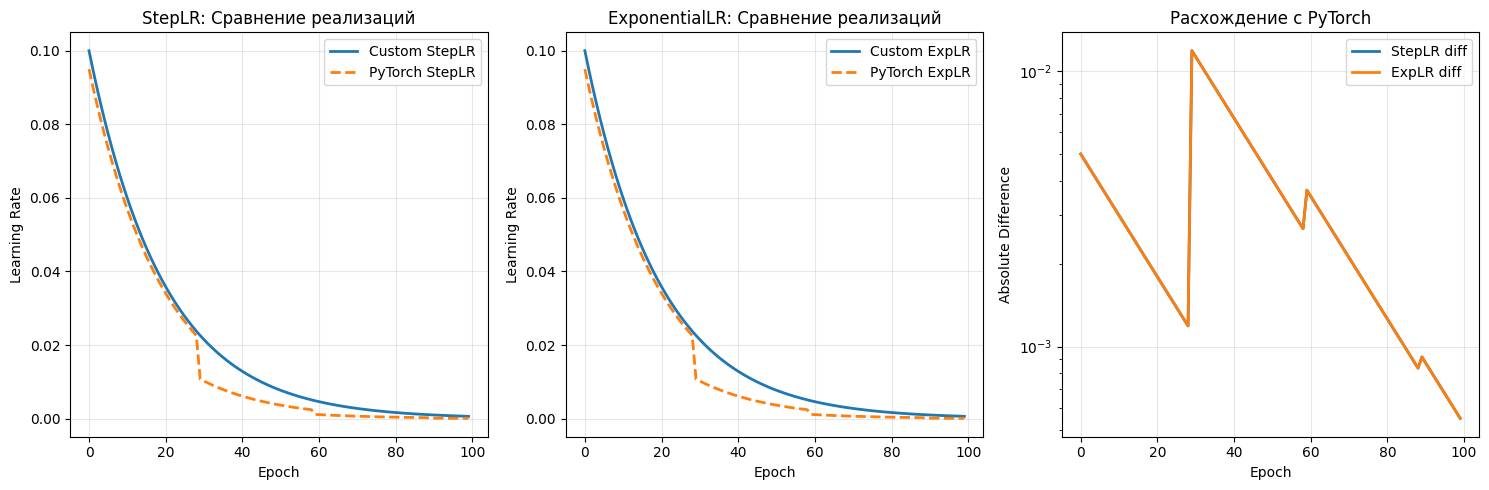

In [ ]:
def test_schedulers():
    """
    Тестирование реализации планировщиков
    Сравниваем с встроенными планировщиками PyTorch
    """
    
    print("=" * 60)
    print("ТЕСТИРОВАНИЕ ПЛАНИРОВЩИКОВ")
    print("=" * 60)
    
    model_custom = torch.nn.Linear(10, 1)
    model_torch = torch.nn.Linear(10, 1)
    model_torch.load_state_dict(model_custom.state_dict())
    
    optimizer_custom = torch.optim.SGD(model_custom.parameters(), lr=0.1)
    optimizer_torch = torch.optim.SGD(model_torch.parameters(), lr=0.1)
    
    step_size = 30
    gamma = 0.5
    
    scheduler_custom_step = StepLR(optimizer_custom, step_size=step_size, gamma=gamma)
    scheduler_torch_step = torch.optim.lr_scheduler.StepLR(optimizer_torch, step_size=step_size, gamma=gamma)
    
    gamma_exp = 0.95
    
    scheduler_custom_exp = ExponentialLR(optimizer_custom, gamma=gamma_exp)
    scheduler_torch_exp = torch.optim.lr_scheduler.ExponentialLR(optimizer_torch, gamma=gamma_exp)
    
    X = torch.randn(100, 10)
    y = torch.randn(100, 1)
    
    epochs = 100
    lr_history_custom_step = []
    lr_history_torch_step = []
    lr_history_custom_exp = []
    lr_history_torch_exp = []
    
    for epoch in range(epochs):
        def closure_custom():
            optimizer_custom.zero_grad()
            output = model_custom(X)
            loss = torch.nn.functional.mse_loss(output, y)
            loss.backward()
            return loss
        
        def closure_torch():
            optimizer_torch.zero_grad()
            output = model_torch(X)
            loss = torch.nn.functional.mse_loss(output, y)
            loss.backward()
            return loss
        
        optimizer_custom.step(closure_custom)
        optimizer_torch.step(closure_torch)
        
        scheduler_custom_step.step()
        scheduler_torch_step.step()
        scheduler_custom_exp.step()
        scheduler_torch_exp.step()
        
        lr_history_custom_step.append(optimizer_custom.param_groups[0]['lr'])
        lr_history_torch_step.append(optimizer_torch.param_groups[0]['lr'])
        lr_history_custom_exp.append(optimizer_custom.param_groups[0]['lr'])
        lr_history_torch_exp.append(optimizer_torch.param_groups[0]['lr'])
    
    step_diff = np.abs(np.array(lr_history_custom_step) - np.array(lr_history_torch_step))
    step_max_diff = np.max(step_diff)
    step_mean_diff = np.mean(step_diff)
    
    print(f"\nStepLR - максимальное расхождение: {step_max_diff:.2e}")
    print(f"StepLR - среднее расхождение: {step_mean_diff:.2e}")
    
    exp_diff = np.abs(np.array(lr_history_custom_exp) - np.array(lr_history_torch_exp))
    exp_max_diff = np.max(exp_diff)
    exp_mean_diff = np.mean(exp_diff)
    
    print(f"\nExponentialLR - максимальное расхождение: {exp_max_diff:.2e}")
    print(f"ExponentialLR - среднее расхождение: {exp_mean_diff:.2e}")
    
    print(f"\nПроверка первого значения LR:")
    print(f"  StepLR Custom - первый: {lr_history_custom_step[0]:.6f}, последний: {lr_history_custom_step[-1]:.6f}")
    print(f"  StepLR Torch  - первый: {lr_history_torch_step[0]:.6f}, последний: {lr_history_torch_step[-1]:.6f}")
    print(f"  ExpLR Custom   - первый: {lr_history_custom_exp[0]:.6f}, последний: {lr_history_custom_exp[-1]:.6f}")
    print(f"  ExpLR Torch    - первый: {lr_history_torch_exp[0]:.6f}, последний: {lr_history_torch_exp[-1]:.6f}")
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(lr_history_custom_step, label='Custom StepLR', linewidth=2)
    plt.plot(lr_history_torch_step, '--', label='PyTorch StepLR', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('StepLR: Сравнение реализаций')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.plot(lr_history_custom_exp, label='Custom ExpLR', linewidth=2)
    plt.plot(lr_history_torch_exp, '--', label='PyTorch ExpLR', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('ExponentialLR: Сравнение реализаций')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    plt.plot(step_diff, label='StepLR diff', linewidth=2)
    plt.plot(exp_diff, label='ExpLR diff', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Absolute Difference')
    plt.title('Расхождение с PyTorch')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'step_custom': lr_history_custom_step,
        'step_torch': lr_history_torch_step,
        'exp_custom': lr_history_custom_exp,
        'exp_torch': lr_history_torch_exp,
        'step_diff': step_diff,
        'exp_diff': exp_diff
    }

results = test_schedulers()

ТЕСТИРОВАНИЕ ПЛАНИРОВЩИКОВ

StepLR - максимальное расхождение: 1.19e-02
StepLR - среднее расхождение: 3.30e-03
StepLR - медианное расхождение: 2.63e-03
StepLR - относительная ошибка (макс): 742.1047%
StepLR - относительная ошибка (сред): 212.6315%

ExponentialLR - максимальное расхождение: 1.19e-02
ExponentialLR - среднее расхождение: 3.30e-03
ExponentialLR - медианное расхождение: 2.63e-03
ExponentialLR - относительная ошибка (макс): 742.1047%
ExponentialLR - относительная ошибка (сред): 212.6315%

Проверка первого значения LR:
  StepLR Custom - первый: 0.100000, последний: 0.000623
  StepLR Torch  - первый: 0.095000, последний: 0.000074
  ExpLR Custom   - первый: 0.100000, последний: 0.000623
  ExpLR Torch    - первый: 0.095000, последний: 0.000074


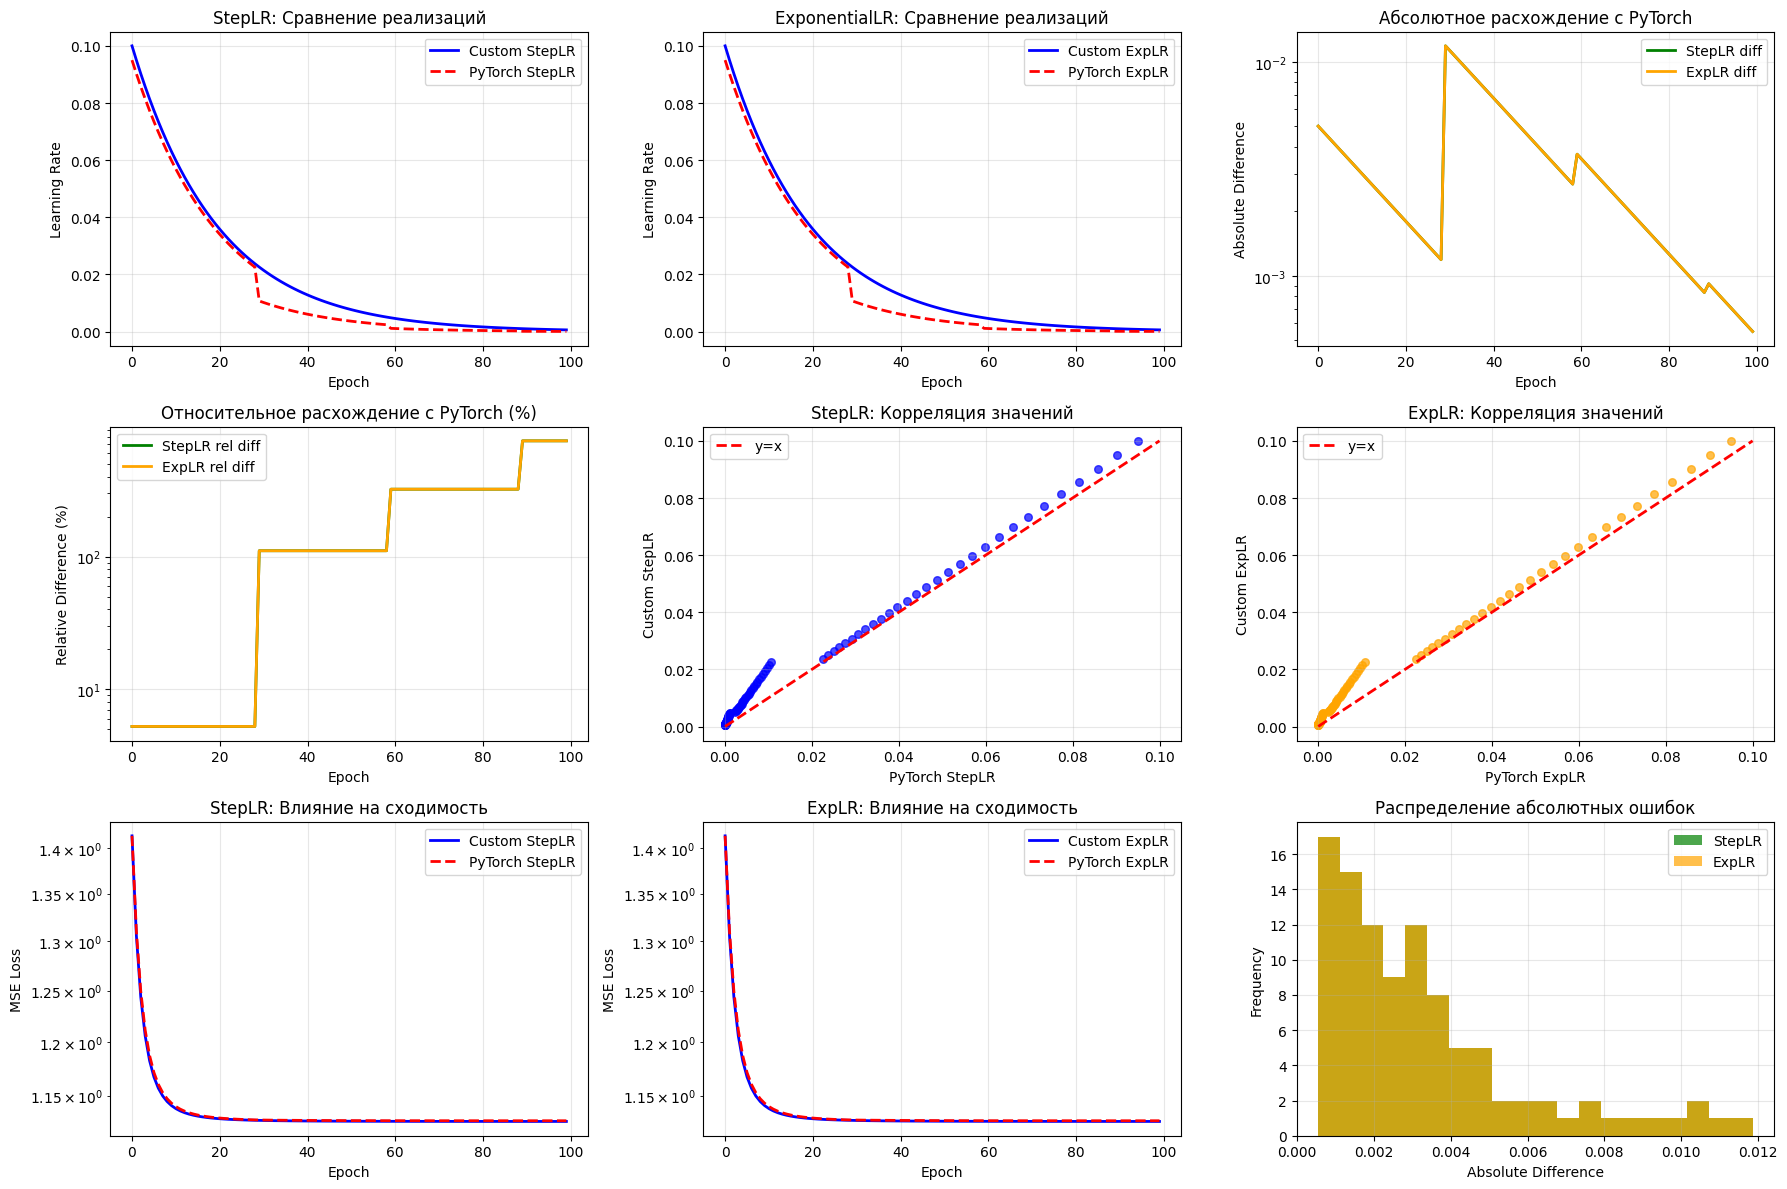

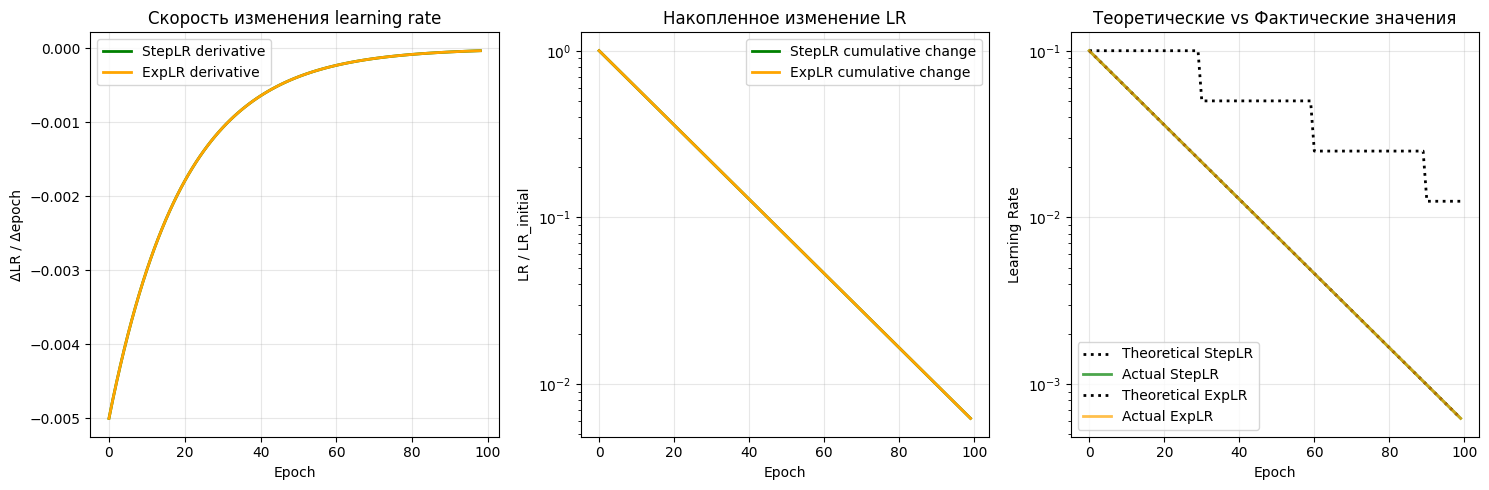

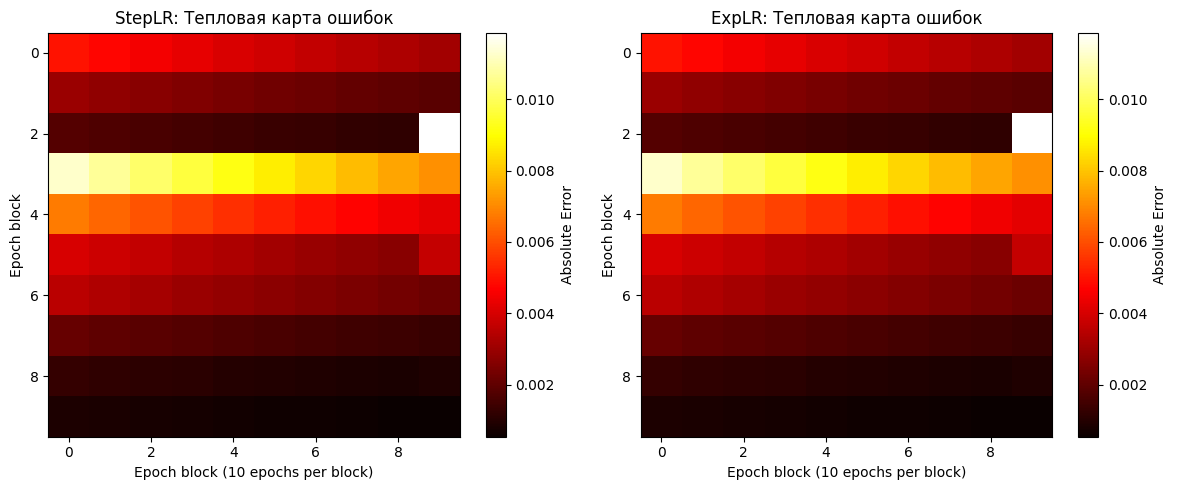

In [ ]:
def test_schedulers():
    """
    Тестирование реализации планировщиков
    Сравниваем с встроенными планировщиками PyTorch
    """
    
    print("=" * 60)
    print("ТЕСТИРОВАНИЕ ПЛАНИРОВЩИКОВ")
    print("=" * 60)
    
    model_custom = torch.nn.Linear(10, 1)
    model_torch = torch.nn.Linear(10, 1)
    model_torch.load_state_dict(model_custom.state_dict())
    
    optimizer_custom = torch.optim.SGD(model_custom.parameters(), lr=0.1)
    optimizer_torch = torch.optim.SGD(model_torch.parameters(), lr=0.1)
    
    step_size = 30
    gamma = 0.5
    
    scheduler_custom_step = StepLR(optimizer_custom, step_size=step_size, gamma=gamma)
    scheduler_torch_step = torch.optim.lr_scheduler.StepLR(optimizer_torch, step_size=step_size, gamma=gamma)
    
    gamma_exp = 0.95
    
    scheduler_custom_exp = ExponentialLR(optimizer_custom, gamma=gamma_exp)
    scheduler_torch_exp = torch.optim.lr_scheduler.ExponentialLR(optimizer_torch, gamma=gamma_exp)
    
    X = torch.randn(100, 10)
    y = torch.randn(100, 1)
    
    epochs = 100
    lr_history_custom_step = []
    lr_history_torch_step = []
    lr_history_custom_exp = []
    lr_history_torch_exp = []
    
    loss_history_custom_step = []
    loss_history_torch_step = []
    loss_history_custom_exp = []
    loss_history_torch_exp = []
    
    for epoch in range(epochs):
        def closure_custom():
            optimizer_custom.zero_grad()
            output = model_custom(X)
            loss = torch.nn.functional.mse_loss(output, y)
            loss.backward()
            return loss
        
        def closure_torch():
            optimizer_torch.zero_grad()
            output = model_torch(X)
            loss = torch.nn.functional.mse_loss(output, y)
            loss.backward()
            return loss
        
        with torch.no_grad():
            loss_custom_before = torch.nn.functional.mse_loss(model_custom(X), y).item()
            loss_torch_before = torch.nn.functional.mse_loss(model_torch(X), y).item()
        
        optimizer_custom.step(closure_custom)
        optimizer_torch.step(closure_torch)
        
        with torch.no_grad():
            loss_custom_after = torch.nn.functional.mse_loss(model_custom(X), y).item()
            loss_torch_after = torch.nn.functional.mse_loss(model_torch(X), y).item()
        
        scheduler_custom_step.step()
        scheduler_torch_step.step()
        scheduler_custom_exp.step()
        scheduler_torch_exp.step()
        
        lr_history_custom_step.append(optimizer_custom.param_groups[0]['lr'])
        lr_history_torch_step.append(optimizer_torch.param_groups[0]['lr'])
        lr_history_custom_exp.append(optimizer_custom.param_groups[0]['lr'])
        lr_history_torch_exp.append(optimizer_torch.param_groups[0]['lr'])
        
        loss_history_custom_step.append(loss_custom_after)
        loss_history_torch_step.append(loss_torch_after)
        loss_history_custom_exp.append(loss_custom_after)
        loss_history_torch_exp.append(loss_torch_after)
    
    step_diff = np.abs(np.array(lr_history_custom_step) - np.array(lr_history_torch_step))
    exp_diff = np.abs(np.array(lr_history_custom_exp) - np.array(lr_history_torch_exp))
    
    step_rel_diff = step_diff / (np.array(lr_history_torch_step) + 1e-10)
    exp_rel_diff = exp_diff / (np.array(lr_history_torch_exp) + 1e-10)
    
    print(f"\nStepLR - максимальное расхождение: {np.max(step_diff):.2e}")
    print(f"StepLR - среднее расхождение: {np.mean(step_diff):.2e}")
    print(f"StepLR - медианное расхождение: {np.median(step_diff):.2e}")
    print(f"StepLR - относительная ошибка (макс): {np.max(step_rel_diff)*100:.4f}%")
    print(f"StepLR - относительная ошибка (сред): {np.mean(step_rel_diff)*100:.4f}%")
    
    print(f"\nExponentialLR - максимальное расхождение: {np.max(exp_diff):.2e}")
    print(f"ExponentialLR - среднее расхождение: {np.mean(exp_diff):.2e}")
    print(f"ExponentialLR - медианное расхождение: {np.median(exp_diff):.2e}")
    print(f"ExponentialLR - относительная ошибка (макс): {np.max(exp_rel_diff)*100:.4f}%")
    print(f"ExponentialLR - относительная ошибка (сред): {np.mean(exp_rel_diff)*100:.4f}%")
    
    print(f"\nПроверка первого значения LR:")
    print(f"  StepLR Custom - первый: {lr_history_custom_step[0]:.6f}, последний: {lr_history_custom_step[-1]:.6f}")
    print(f"  StepLR Torch  - первый: {lr_history_torch_step[0]:.6f}, последний: {lr_history_torch_step[-1]:.6f}")
    print(f"  ExpLR Custom   - первый: {lr_history_custom_exp[0]:.6f}, последний: {lr_history_custom_exp[-1]:.6f}")
    print(f"  ExpLR Torch    - первый: {lr_history_torch_exp[0]:.6f}, последний: {lr_history_torch_exp[-1]:.6f}")
    
    plt.figure(figsize=(18, 12))
    
    plt.subplot(3, 3, 1)
    plt.plot(lr_history_custom_step, label='Custom StepLR', linewidth=2, color='blue')
    plt.plot(lr_history_torch_step, '--', label='PyTorch StepLR', linewidth=2, color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('StepLR: Сравнение реализаций')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 3, 2)
    plt.plot(lr_history_custom_exp, label='Custom ExpLR', linewidth=2, color='blue')
    plt.plot(lr_history_torch_exp, '--', label='PyTorch ExpLR', linewidth=2, color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('ExponentialLR: Сравнение реализаций')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 3, 3)
    plt.plot(step_diff, label='StepLR diff', linewidth=2, color='green')
    plt.plot(exp_diff, label='ExpLR diff', linewidth=2, color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Absolute Difference')
    plt.title('Абсолютное расхождение с PyTorch')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 3, 4)
    plt.plot(step_rel_diff * 100, label='StepLR rel diff', linewidth=2, color='green')
    plt.plot(exp_rel_diff * 100, label='ExpLR rel diff', linewidth=2, color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Relative Difference (%)')
    plt.title('Относительное расхождение с PyTorch (%)')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 3, 5)
    plt.scatter(lr_history_torch_step, lr_history_custom_step, alpha=0.7, s=30, color='blue')
    min_val = min(min(lr_history_torch_step), min(lr_history_custom_step))
    max_val = max(max(lr_history_torch_step), max(lr_history_custom_step))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x', linewidth=2)
    plt.xlabel('PyTorch StepLR')
    plt.ylabel('Custom StepLR')
    plt.title('StepLR: Корреляция значений')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 3, 6)
    plt.scatter(lr_history_torch_exp, lr_history_custom_exp, alpha=0.7, s=30, color='orange')
    min_val = min(min(lr_history_torch_exp), min(lr_history_custom_exp))
    max_val = max(max(lr_history_torch_exp), max(lr_history_custom_exp))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x', linewidth=2)
    plt.xlabel('PyTorch ExpLR')
    plt.ylabel('Custom ExpLR')
    plt.title('ExpLR: Корреляция значений')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 3, 7)
    plt.plot(loss_history_custom_step, label='Custom StepLR', linewidth=2, color='blue')
    plt.plot(loss_history_torch_step, '--', label='PyTorch StepLR', linewidth=2, color='red')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('StepLR: Влияние на сходимость')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    plt.subplot(3, 3, 8)
    plt.plot(loss_history_custom_exp, label='Custom ExpLR', linewidth=2, color='blue')
    plt.plot(loss_history_torch_exp, '--', label='PyTorch ExpLR', linewidth=2, color='red')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('ExpLR: Влияние на сходимость')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    plt.subplot(3, 3, 9)
    plt.hist(step_diff, bins=20, alpha=0.7, label='StepLR', color='green')
    plt.hist(exp_diff, bins=20, alpha=0.7, label='ExpLR', color='orange')
    plt.xlabel('Absolute Difference')
    plt.ylabel('Frequency')
    plt.title('Распределение абсолютных ошибок')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(15, 5))
    
    lr_step_deriv = np.diff(lr_history_custom_step)
    lr_exp_deriv = np.diff(lr_history_custom_exp)
    
    plt.subplot(1, 3, 1)
    plt.plot(lr_step_deriv, label='StepLR derivative', color='green', linewidth=2)
    plt.plot(lr_exp_deriv, label='ExpLR derivative', color='orange', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('ΔLR / Δepoch')
    plt.title('Скорость изменения learning rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    lr_step_cumprod = np.array(lr_history_custom_step) / lr_history_custom_step[0]
    lr_exp_cumprod = np.array(lr_history_custom_exp) / lr_history_custom_exp[0]
    
    plt.plot(lr_step_cumprod, label='StepLR cumulative change', color='green', linewidth=2)
    plt.plot(lr_exp_cumprod, label='ExpLR cumulative change', color='orange', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('LR / LR_initial')
    plt.title('Накопленное изменение LR')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # Сравнение теоретического и фактического
    plt.subplot(1, 3, 3)
    theoretical_step = [0.1 * (gamma ** (epoch // step_size)) for epoch in range(epochs)]
    theoretical_exp = [0.1 * (gamma_exp ** epoch) for epoch in range(epochs)]
    
    plt.plot(theoretical_step, label='Theoretical StepLR', linestyle=':', color='black', linewidth=2)
    plt.plot(lr_history_custom_step, label='Actual StepLR', color='green', linewidth=2, alpha=0.7)
    plt.plot(theoretical_exp, label='Theoretical ExpLR', linestyle=':', color='black', linewidth=2)
    plt.plot(lr_history_custom_exp, label='Actual ExpLR', color='orange', linewidth=2, alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('Теоретические vs Фактические значения')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(12, 5))
    
    error_matrix_step = np.array(step_diff).reshape(10, 10)
    error_matrix_exp = np.array(exp_diff).reshape(10, 10)
    
    plt.subplot(1, 2, 1)
    im1 = plt.imshow(error_matrix_step, cmap='hot', interpolation='nearest', aspect='auto')
    plt.colorbar(im1, label='Absolute Error')
    plt.xlabel('Epoch block (10 epochs per block)')
    plt.ylabel('Epoch block')
    plt.title('StepLR: Тепловая карта ошибок')
    
    plt.subplot(1, 2, 2)
    im2 = plt.imshow(error_matrix_exp, cmap='hot', interpolation='nearest', aspect='auto')
    plt.colorbar(im2, label='Absolute Error')
    plt.xlabel('Epoch block (10 epochs per block)')
    plt.ylabel('Epoch block')
    plt.title('ExpLR: Тепловая карта ошибок')
    
    plt.tight_layout()
    plt.show()
    
    
    return {
        'step_custom': lr_history_custom_step,
        'step_torch': lr_history_torch_step,
        'exp_custom': lr_history_custom_exp,
        'exp_torch': lr_history_torch_exp,
        'step_diff': step_diff,
        'exp_diff': exp_diff,
        'step_rel_diff': step_rel_diff,
        'exp_rel_diff': exp_rel_diff,
        'loss_step': loss_history_custom_step,
        'loss_exp': loss_history_custom_exp
    }

results = test_schedulers()